# Complete HER Kinetic Fitting Tutorial
This notebook demonstrates how to programmatically use the `HydrogenFitting` kinetic engine to analyze LSV data for the Hydrogen Evolution Reaction (HER). 

It replicates **all the functionality** of the web application backend, including loading data, trimming points by potential, setting parameter boundaries, non-linear fitting, plotting, and exporting the results.

In [35]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add the parent directory to the python path so we can import the webapp module
sys.path.append(os.path.abspath('.'))

from webapp.models.hydrogen import hydrogen_fitting

# Set matplotlib style for nice plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 1. Load the Dataset and Set Electrochemical Parameters
We load the sample dataset and define the experimental conditions such as geometric area, ohmic drop, reference potential, and pH.

**Important:** Ensure `current_col` and `potential_col` correctly match your dataset. 
- In `Pt_example.txt`, Potential is in column 1 and Current is in column 2.
- In `Mo2C...txt`, Current is in column 1 and Potential is in column 2.

In [72]:
# Path to your LSV data file
file_path = r"C:/Users/xxx/Mo2C_example.txt"

# Initialize the fitting engine with parameters exactly as the web app form does
fitter = hydrogen_fitting(
    file_path=file_path,
    current_col=1,          # 1-indexed column for Current (e.g., Column 2)
    potential_col=2,        # 1-indexed column for Potential (e.g., Column 1)
    delimiter='auto',       # Auto-detect delimiter ('\t', ',', etc)
    
    # Data Cropping (Trim points based on raw potential)
    potential_min=None,     # Keep only data where Potential >= potential_min (e.g., -1.2). None to disable.
    potential_max=None,     # Keep only data where Potential <= potential_max (e.g., -0.9). None to disable.
    
    # Electrochemical Condition Parameters
    temperature=298.15,     # Temperature in Kelvin
    pH=14.0,                # pH of the electrolyte
    ref_potential=0.098,    # E_ref^0 (V vs SHE). 0.098 V is for Hg/HgO.
    area_electrode=0.196,   # Geometric area of the electrode in cm^2
    ohmic_drop=6.44,        # Uncompensated resistance (Ru) in Ohms
    
    # Advanced Parameter Controls (Limits, Bounds, and Constraints)
    # k1 (Volmer Fwd)
    k1_initial=None,        # Set to None for auto-randomization
    k1_min=1e-30,
    k1_max=1e-2,
    vary_k1=True,           # True to fit, False to fix
    
    # k1r (Volmer Rev)
    k1r_initial=None,
    k1r_min=1e-30,
    k1r_max=1e-2,
    vary_k1r=True,
    
    # k2 (Heyrovsky Fwd)
    k2_initial=None,
    k2_min=1e-30,
    k2_max=1e-2,
    vary_k2=True,
    
    # k2r (Heyrovsky Rev)
    k2r_initial=None,
    k2r_min=1e-30,
    k2r_max=1e-2,
    vary_k2r=True,
    
    # k3 (Tafel Fwd)
    k3_initial=None,
    k3_min=1e-30,
    k3_max=1e-2,
    vary_k3=True,
    
    # k3r (Tafel Rev)
    k3r_initial=None,
    k3r_min=1e-20,
    k3r_max=1e-2,
    vary_k3r=True,
    
    # Symmetry Factors (Beta V and Beta H)
    bbv_initial=0.5,
    bbv_min=0.01,
    bbv_max=1,
    vary_bbv=False,         # Usually recommended to keep fixed
    
    bbh_initial=0.5,
    bbh_min=0.01,
    bbh_max=1,
    vary_bbh=False,
)


import numpy as np

# Data Cropping by Normalized Current (mA cm-2)
# Since HER currents are negative, current >= -100 means -99, -98...
# current <= -10 means -11, -12...
current_min_mA = -100  # None to disable
current_max_mA = -10   # None to disable

current_mA = fitter.current * 1000  # fitter.current is in A cm-2, convert to mA cm-2
mask_current = np.ones_like(current_mA, dtype=bool)

if current_min_mA is not None:
    mask_current &= (current_mA >= current_min_mA)
if current_max_mA is not None:
    mask_current &= (current_mA <= current_max_mA)

if not np.all(mask_current):
    fitter.potential = fitter.potential[mask_current]
    fitter.current = fitter.current[mask_current]
    fitter.current_density = fitter.current_density[mask_current]

print(f"Loaded {len(fitter.potential)} valid data points after processing.")


Loaded 74 valid data points after processing.


## 2. Run the Kinetic Fitting
Configure the advanced optimizer parameters and run the global + local search.

In [76]:
model_type = 'Volmer-Heyrovsky' # Can also be 'Volmer-Tafel' or 'Volmer-Heyrovsky-Tafel'

# Perform the non-linear kinetic fit
fitter.fit_data(
    model_type=model_type,
    fitting_method='least_squares',           # Local solver: bounded least squares
    use_global_search=True,                   # True to use Differential Evolution first
    global_method='differential_evolution',   # Global search algorithm
    n_starts=100,                               # Number of random starts for robustness
    max_nfev_global=1000,                     # Global max iterations
    robust_loss='soft_l1'                     # Robust loss function for local minimization
)

print("Fit completed successfully!")

C:\Users\jamee\miniconda3\Lib\site-packages\lmfit\minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = np.sqrt(self.result.covar[ivar, ivar])
C:\Users\jamee\miniconda3\Lib\site-packages\lmfit\minimizer.py:826: RuntimeWarning: invalid value encountered in sqrt
  (par.stderr * np.sqrt(self.result.covar[jvar, jvar])))
C:\Users\jamee\miniconda3\Lib\site-packages\uncertainties\core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs = numpy.sqrt(numpy.diag(covariance_mat))
C:\Users\jamee\miniconda3\Lib\site-packages\lmfit\minimizer.py:819: RuntimeWarning: invalid value encountered in sqrt
  par.stderr = np.sqrt(self.result.covar[ivar, ivar])
C:\Users\jamee\miniconda3\Lib\site-packages\lmfit\minimizer.py:826: RuntimeWarning: invalid value encountered in sqrt
  (par.stderr * np.sqrt(self.result.covar[jvar, jvar])))
C:\Users\jamee\miniconda3\Lib\site-packages\uncertainties\core.py:116: RuntimeWarning: invalid value encountered in sqrt
  std_devs =

Fit completed successfully!


## 3. View the Fit Report and Extracted Parameters
The `.get_stats()` and `.get_params_dict()` functions provide the programmatic outputs.

In [77]:
stats = fitter.get_stats()
print(f"R-squared: {stats['r_squared']:.4f}")
print(f"Reduced Chi-square: {stats['redchi']:.3e}")
print(f"AIC: {stats['aic']:.2f}\n")

print("---- Extracted Kinetic Parameters ----")
params_dict = fitter.get_params_dict()
for key, val in params_dict.items():
    print(f"{key}: {val:.4e}")

print("\n---- Full lmfit Report ----")
print(fitter.result_model.fit_report())

R-squared: 0.9710
Reduced Chi-square: 7.195e+00
AIC: 148.97

---- Extracted Kinetic Parameters ----
k1: 3.7928e-09
k1r: 1.0000e-30
k2: 2.5806e-06
k2r: 9.8665e-03
bbv: 5.0000e-01
bbh: 5.0000e-01

---- Full lmfit Report ----
[[Model]]
    Model(model_func)
[[Fit Statistics]]
    # fitting method   = least_squares
    # function evals   = 59
    # data points      = 74
    # variables        = 3
    chi-square         = 510.842587
    reduced chi-square = 7.19496601
    Akaike info crit   = 148.967734
    Bayesian info crit = 155.879929
    R-squared          = 0.97101922
[[Variables]]
    log_k1:  -19.3901690 +/- 23.0115512 (118.68%) (init = -19.9538)
    k1:       3.7928e-09 +/- 8.7278e-08 (2301.16%) == 'exp(log_k1)'
    log_k1r: -69.07755 (fixed)
    k1r:      1.0000e-30 +/- 0.00000000 (0.00%) == 'exp(log_k1r)'
    log_k2:  -12.8675034 +/- 15646.4873 (121596.92%) (init = -6.667245)
    k2:       2.5806e-06 +/- 0.04037673 (1564648.73%) == 'exp(log_k2)'
    log_k2r: -4.61861433 +/- 15623

## 4. Replicate Web App Visualizations
We will generate the Polarization Curve, Surface Coverage ($\theta_H$), and Tafel Slope plots using the exact same aesthetics as the web app.

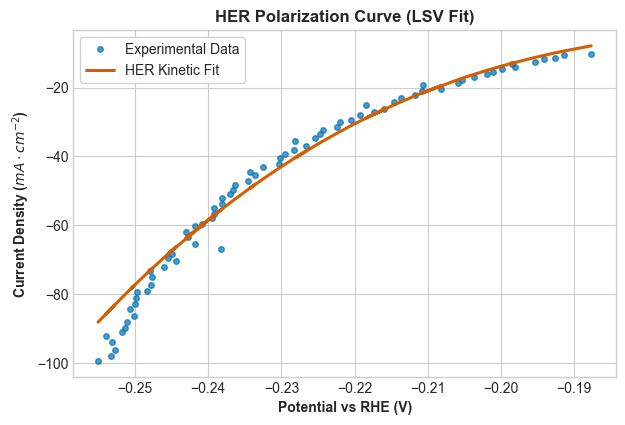

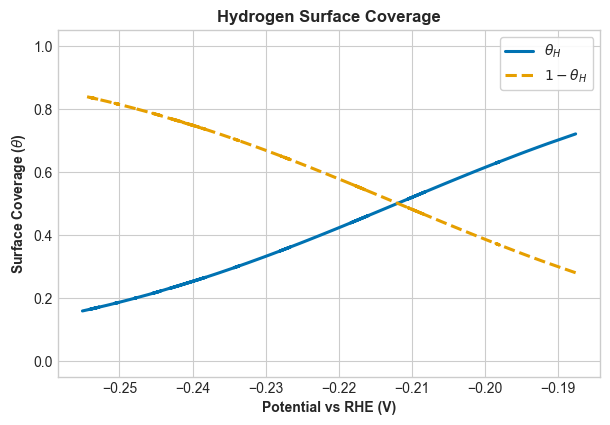

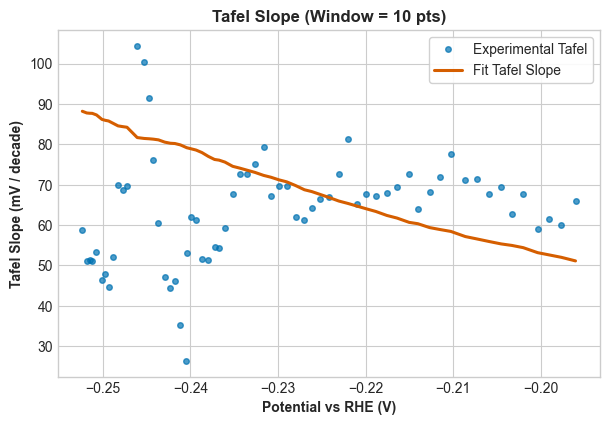

In [78]:
# Plot 1: Polarization Curve
fig1, ax1 = plt.subplots(figsize=(7, 4.5), dpi=100)
x_data = fitter.potential
y_data = fitter.current * 1000  # Convert to mA for plotting
y_fit = fitter.result_model.eval(x=x_data) * 1000

ax1.plot(x_data, y_data, 'o', color='#0072B2', markersize=4, alpha=0.7, label='Experimental Data')
ax1.plot(x_data, y_fit, '-', color='#D55E00', linewidth=2.2, label='HER Kinetic Fit')

ax1.set_xlabel('Potential vs RHE (V)', fontweight='bold')
ax1.set_ylabel(r'Current Density ($mA \cdot cm^{-2}$)', fontweight='bold')
ax1.set_title('HER Polarization Curve (LSV Fit)', fontweight='bold')
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.show()

# Plot 2: Surface Coverage
theta_H, theta_empty = fitter.compute_theta()
fig2, ax2 = plt.subplots(figsize=(7, 4.5), dpi=100)
ax2.plot(x_data, theta_H, '-', color='#0072B2', linewidth=2.2, label=r'$\theta_H$')
ax2.plot(x_data, theta_empty, '--', color='#E69F00', linewidth=2.2, label=r'$1 - \theta_H$')

ax2.set_xlabel('Potential vs RHE (V)', fontweight='bold')
ax2.set_ylabel(r'Surface Coverage ($\theta$)', fontweight='bold')
ax2.set_title(r'Hydrogen Surface Coverage', fontweight='bold')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.show()

# Plot 3: Tafel Slope
window_size = 10
skip_points = 0
tafel_exp = fitter.compute_tafel_slope(use_fitted=False, window_size=window_size, skip_initial=skip_points)
tafel_fit = fitter.compute_tafel_slope(use_fitted=True, window_size=window_size, skip_initial=skip_points)

if isinstance(tafel_exp, tuple): x_exp_t, y_exp_t = tafel_exp
else: x_exp_t, y_exp_t = tafel_exp[:, 0], tafel_exp[:, 1]
if isinstance(tafel_fit, tuple): x_fit_t, y_fit_t = tafel_fit
else: x_fit_t, y_fit_t = tafel_fit[:, 0], tafel_fit[:, 1]

fig3, ax3 = plt.subplots(figsize=(7, 4.5), dpi=100)
ax3.plot(x_exp_t, y_exp_t, 'o', color='#0072B2', markersize=4, alpha=0.7, label='Experimental Tafel')
ax3.plot(x_fit_t, y_fit_t, '-', color='#D55E00', linewidth=2.2, label='Fit Tafel Slope')

ax3.set_xlabel('Potential vs RHE (V)', fontweight='bold')
ax3.set_ylabel('Tafel Slope (mV / decade)', fontweight='bold')
ax3.set_title(f'Tafel Slope (Window = {window_size} pts)', fontweight='bold')
ax3.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.show()

## 5. Export Everything (Same as 'Export Results (ZIP)')
Instead of creating a ZIP in memory, we will save the CSVs, JSON metadata, and PNGs to a local `results/` folder.

In [79]:
import os
import json
import pandas as pd

export_dir = 'results'
os.makedirs(export_dir, exist_ok=True)

# Extract a safe base name from the file_path to prefix the exported files
try:
    base_name = os.path.splitext(os.path.basename(file_path))[0]
    prefix = f"{base_name}_" if base_name else ""
except NameError:
    prefix = ""

# 1. Save Fit Report
with open(os.path.join(export_dir, f'{prefix}Fit_Report.txt'), 'w', encoding='utf-8') as f:
    f.write(fitter.result_model.fit_report())

# 2. Save Metadata JSON
metadata = {
    "model_type": model_type,
    "temperature_K": 298.15,
    "pH": 14.0,
    "area_electrode_cm2": 0.196,
    "ohmic_drop_ohm": 6.05,
    "ref_potential_V_vs_SHE": 0.098,
    "stats": stats
}
with open(os.path.join(export_dir, f'{prefix}fit_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

# 3. Export Polarization Curve CSV (with raw residuals)
# Note: y_data and y_fit are in Amperes internally in the model
df_polarization = pd.DataFrame({
    'potential_corrected_V': x_data,
    'current_exp_A': fitter.current,
    'current_fit_A': fitter.result_model.eval(x=x_data),
    'residual_raw_A': fitter.result_model.eval(x=x_data) - fitter.current
})
df_polarization.to_csv(os.path.join(export_dir, f'{prefix}polarization_curve.csv'), index=False)

# 4. Export Theta Coverage CSV
df_theta = pd.DataFrame({
    'Potential_V': x_data,
    'Theta_H': theta_H,
    'Theta_Empty': theta_empty
})
df_theta.to_csv(os.path.join(export_dir, f'{prefix}theta_coverage.csv'), index=False)

# 5. Export Tafel Slope CSV
min_len = min(len(x_exp_t), len(x_fit_t))
df_tafel = pd.DataFrame({
    'Potential_V': x_exp_t[:min_len],
    'Tafel_Slope_Data_mV_dec': y_exp_t[:min_len],
    'Tafel_Slope_Fit_mV_dec': y_fit_t[:min_len]
})
df_tafel.to_csv(os.path.join(export_dir, f'{prefix}tafel_slope.csv'), index=False)

# 6. Export PNG Figures
fig1.savefig(os.path.join(export_dir, f'{prefix}polarization_curve.png'), dpi=150, bbox_inches='tight')
fig2.savefig(os.path.join(export_dir, f'{prefix}theta_coverage.png'), dpi=150, bbox_inches='tight')
fig3.savefig(os.path.join(export_dir, f'{prefix}tafel_slope.png'), dpi=150, bbox_inches='tight')

print(f"All data and figures successfully exported to the '{export_dir}' folder with prefix '{prefix}'.")



All data and figures successfully exported to the 'results' folder with prefix 'LSV_Mo2C_EF3_3(2)_'.


## 6. Scenario: Irreversible Reverse Steps (Assuming k1r and k2r = 0)
If you want to assume that the backward oxidation reactions are negligible (irreversible HER), you can fix the reverse rate constants (`k1r` and `k2r`) to zero.

Since the optimizer works in logarithmic space, we cannot use exactly `0.0`. Instead, we fix the reverse rate constants to an extremely small floor value (`1e-30`) by setting `vary=False`.

In [ ]:
# Re-initialize with reverse constants fixed to ~0
fitter_irrev = hydrogen_fitting(
    file_path=file_path,
    current_col=2,
    potential_col=1,
    
    # Standard parameters
    temperature=298.15,
    pH=14.0,
    ref_potential=0.098,
    area_electrode=0.196,
    ohmic_drop=6.05,
    
    # Forward reactions (Vary = True)
    vary_k1=True,
    vary_k2=True,
    vary_k3=True,     # Keep Tafel active if needed
    
    # IRREVERSIBLE ASSUMPTION: Fix reverse rates to 1e-30
    vary_k1r=False, k1r_initial=1e-30,
    vary_k2r=False, k2r_initial=1e-30,
    # vary_k3r is left out of this assumption as per request, so it uses defaults (varies)
)

fitter_irrev.fit_data(model_type='Volmer-Heyrovsky-Tafel', use_global_search=True, n_starts=3)

print("---- Irreversible Scenario Fit ----")
stats_irrev = fitter_irrev.get_stats()
print(f"R-squared: {stats_irrev['r_squared']:.4f}")
print("Extracted Parameters:")
for key, val in fitter_irrev.get_params_dict().items():
    print(f"  {key}: {val:.4e}")